# (27) BALLS: Test

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:0```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from base.helper import find_weight_concentrations
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Load

In [3]:
model_name = 'gaussian_sigmoid_BALLS16_t-16_z-[32]_cl-5,5_<grad|lin>'
fit_name = 'b400-ep2000-lr(0.002)_beta(16:0.1)_gr(5000)_(2025_02_28,15:04)'

# model_name = 'gaussian_relu_BALLS16_t-16_z-[32]_cl-5,5_<grad|lin>'
# fit_name = 'b400-ep2000-lr(0.002)_beta(16:0.1)_gr(5000)_(2025_02_28,15:02)'

# model_name = 'poisson_BALLS16_t-64_z-[32]_cl-10,10_<grad|lin>'
# fit_name = 'b400-ep2000-lr(0.002)_beta(32:0.1)_temp(0.01:0.5)_gr(5000)_(2025_02_27,16:59)'

tr, meta = load_model(f"{model_name}/{fit_name}", device)
print(meta)

{
    'timestamp': '2025_02_28,15:04',
    'checkpoint': 2000,
    'global_step': 300000,
    'root': 
'/home/hadi/Projects/PoissonVAE/models/gaussian_sigmoid_BALLS16_t-16_z-[32]_cl-5,5_<grad|lin>/b400-ep2000-lr(0.002)
_beta(16:0.1)_gr(5000)_(2025_02_28,15:04)',
    'file': 'IGVAE+Trainer-2000_(2025_02_28,18:58).pt'
}

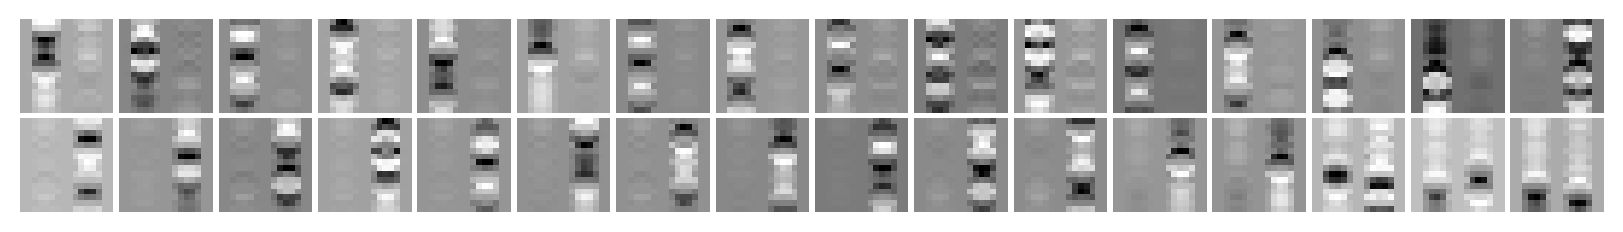

In [4]:
w = tr.model.layer.get_weight()
w = tonp(w.T).reshape(32, 16, 16)
ordered_indices, centers = find_weight_concentrations(
    w, lambda p: p[0] + (p[1] > 6).astype(float) * 50)

tr.model.show(order=ordered_indices, nrows=2);

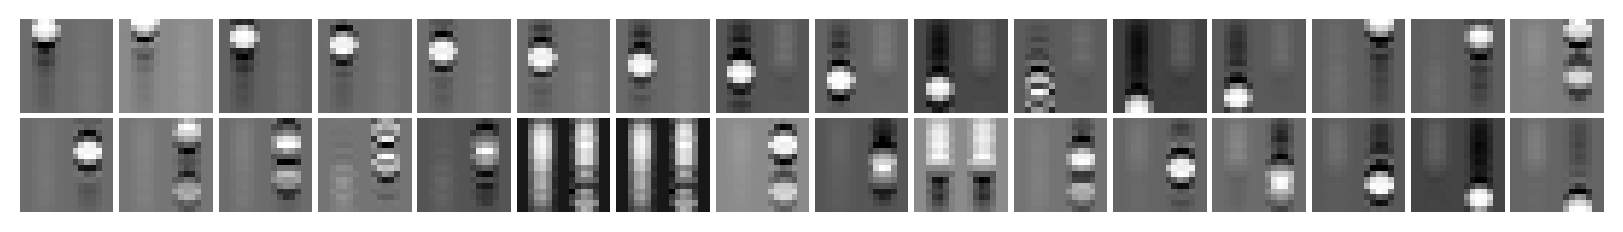

In [4]:
### Was: Gaussian-ReLu (16, 16.0)

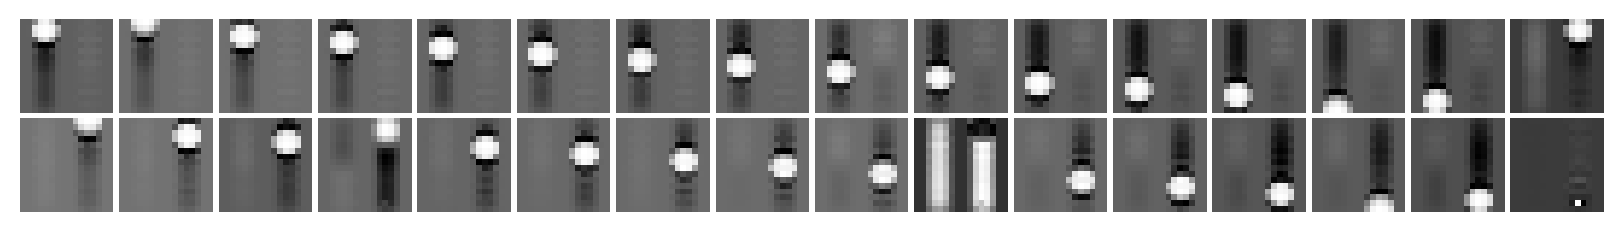

In [4]:
### Was: Poisson (64, 32.0)

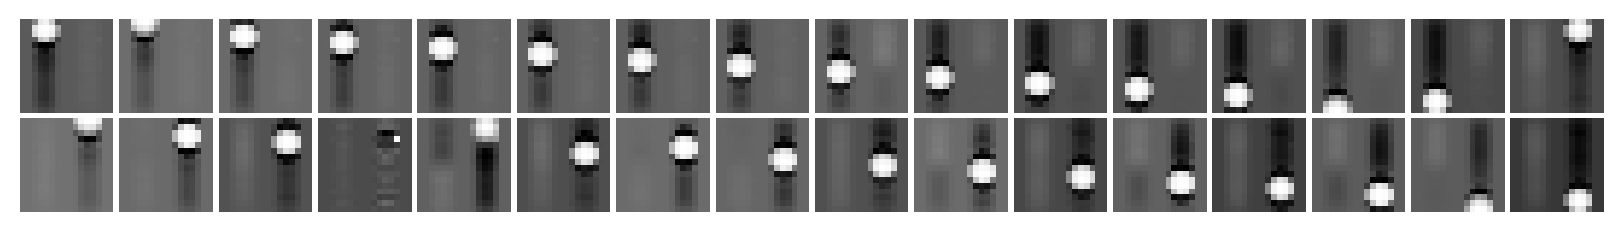

In [4]:
### Was: (16, 16.0)

100%|███████████████████████████████████| 5/5 [00:07<00:00,  1.53s/it]


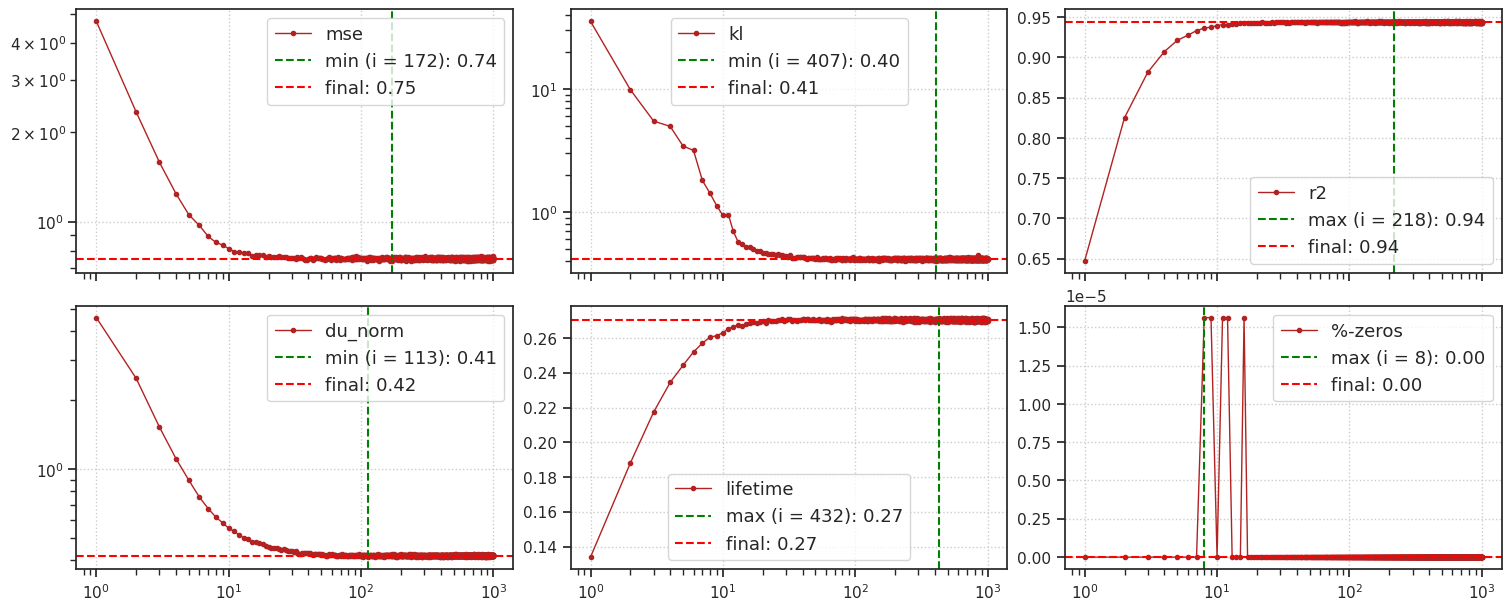

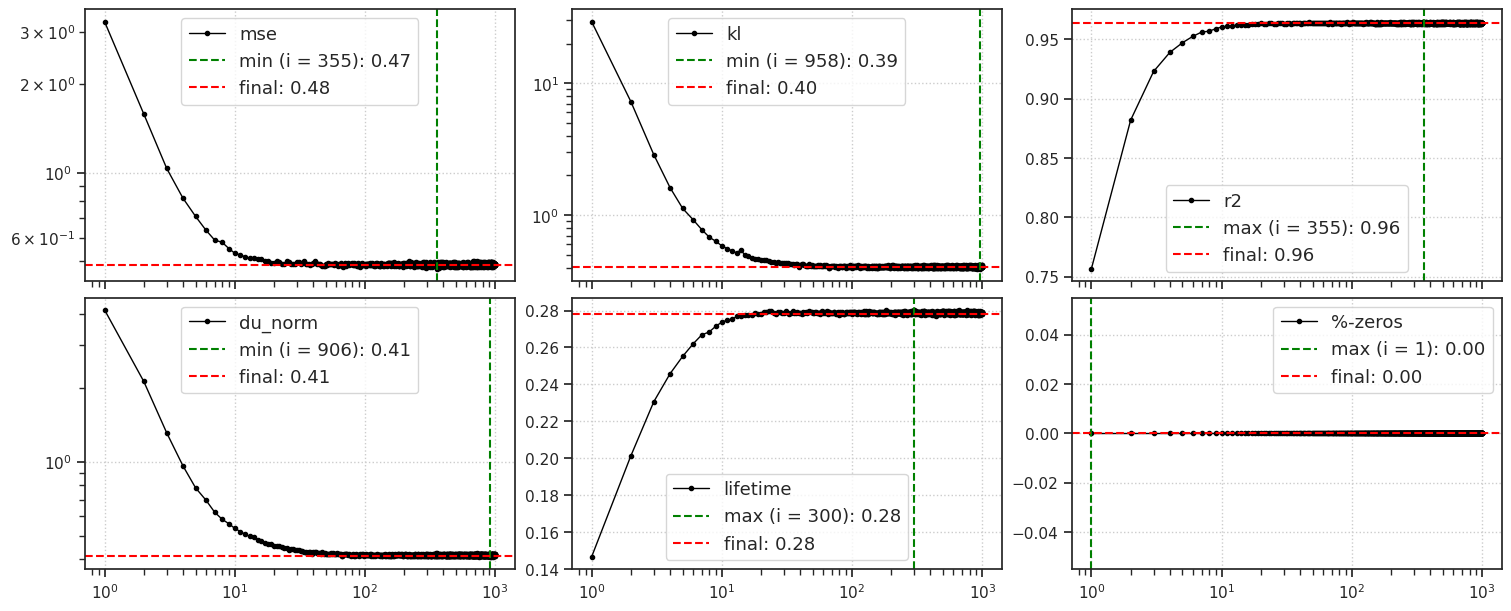

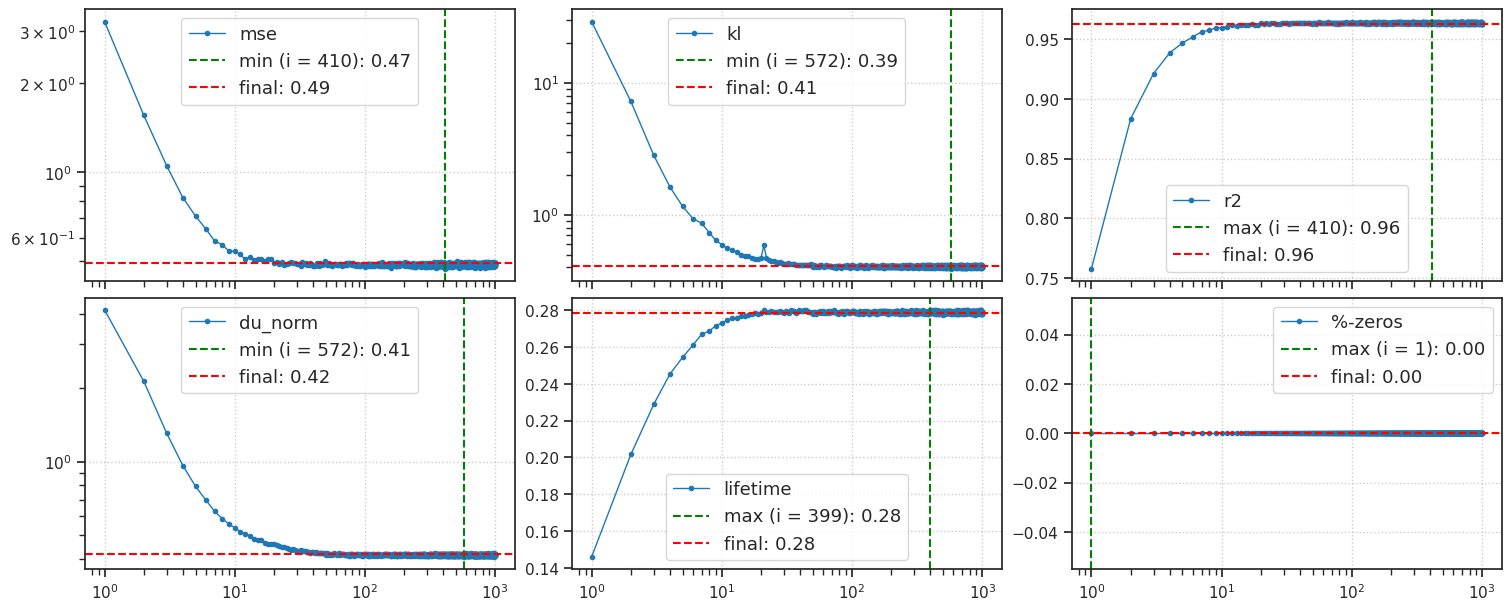

CPU times: user 27.8 s, sys: 464 ms, total: 28.3 s
Wall time: 28.3 s


In [5]:
%%time

kws = dict(
    seq_total=1000,
    seq_batch_sz=1000,
    n_data_batches=5,
)
results = {
    k: tr.analysis(k, **kws)
    for k in ['tst', 'vld', 'trn']
}
# plot
_ = plot_convergence(results['tst'], color='firebrick')
_ = plot_convergence(results['vld'], color='k')
_ = plot_convergence(results['trn'], color='C0')

100%|███████████████████████████████████| 5/5 [00:07<00:00,  1.51s/it]


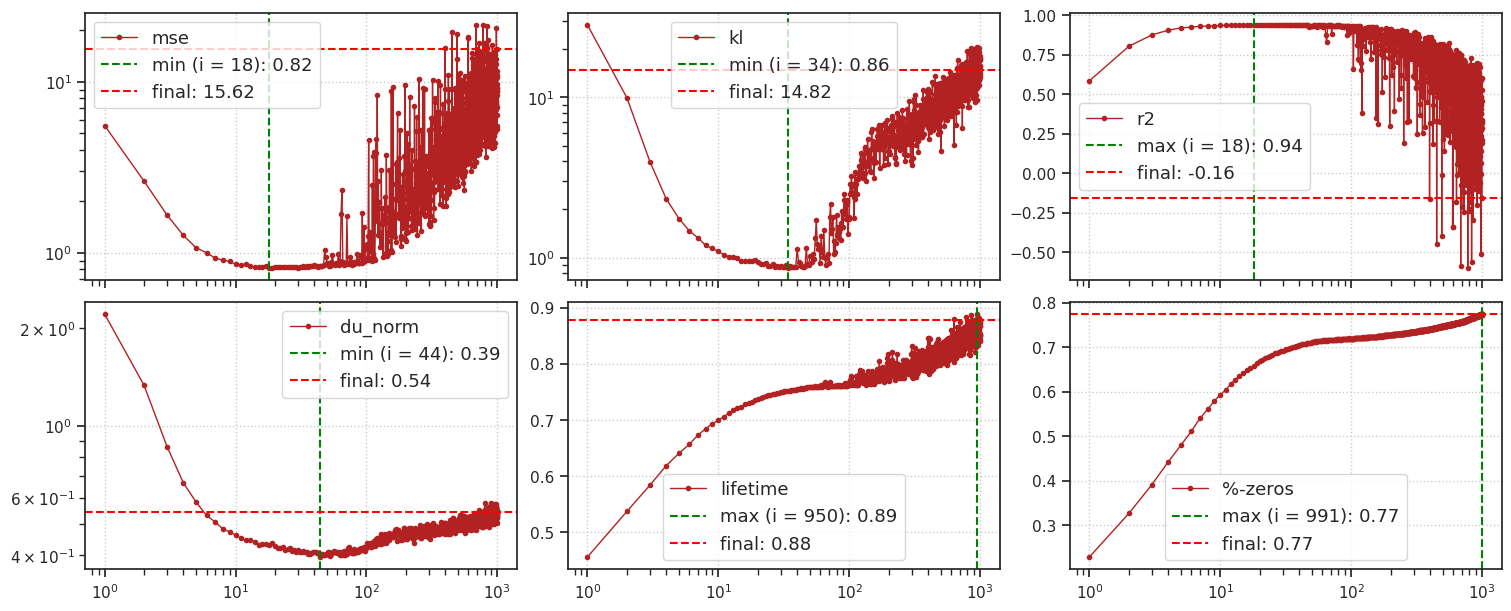

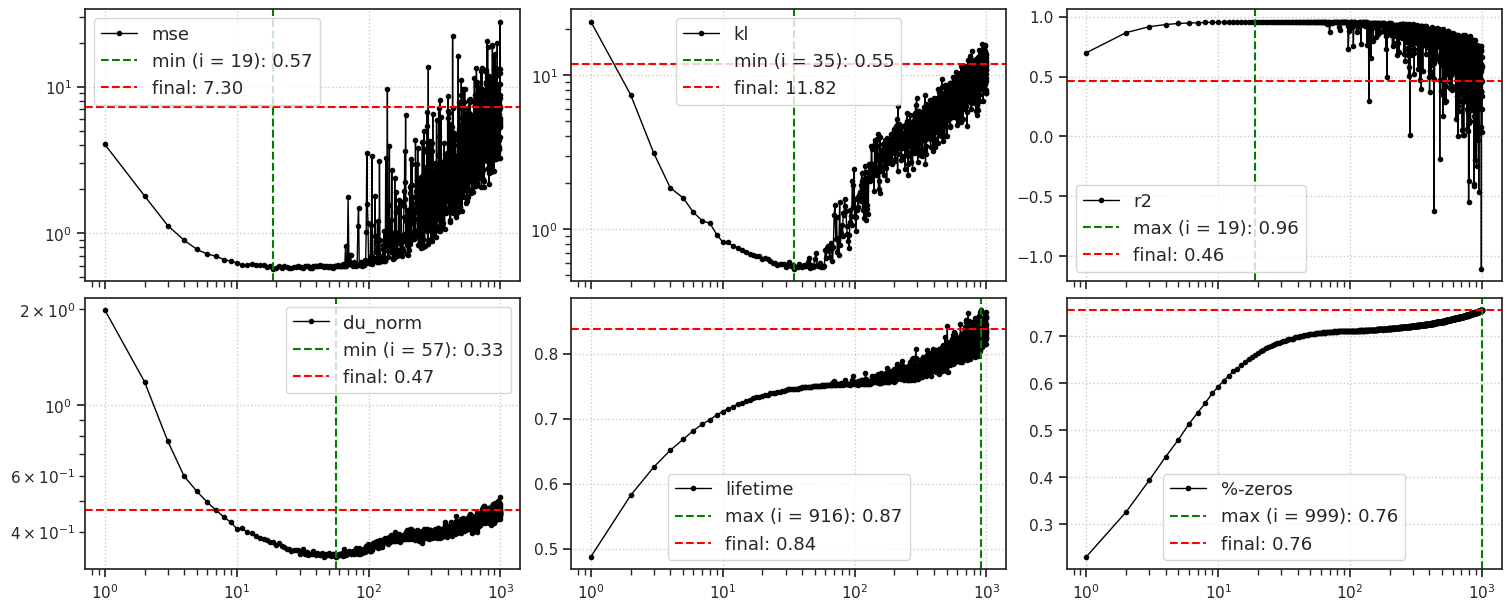

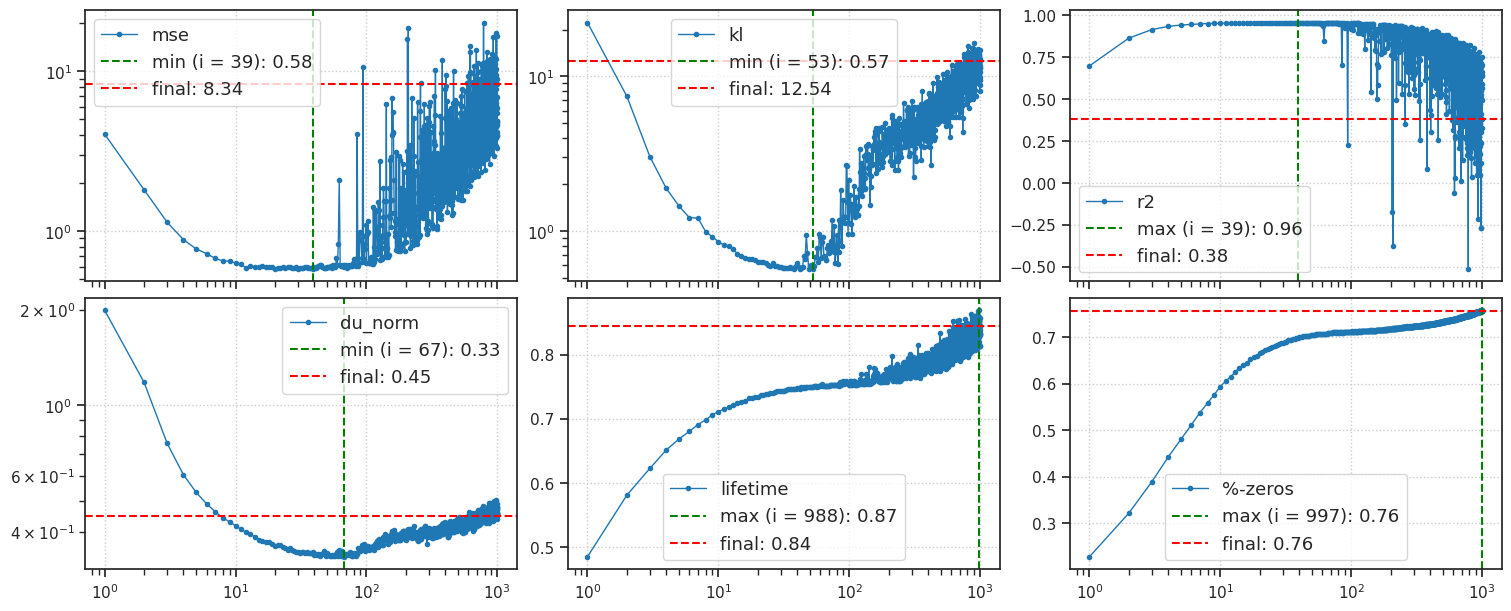

CPU times: user 27.6 s, sys: 401 ms, total: 28 s
Wall time: 28 s


In [5]:
### Was: Gaussian-ReLu (16, 16.0)

100%|███████████████████████████████████| 5/5 [00:09<00:00,  1.91s/it]


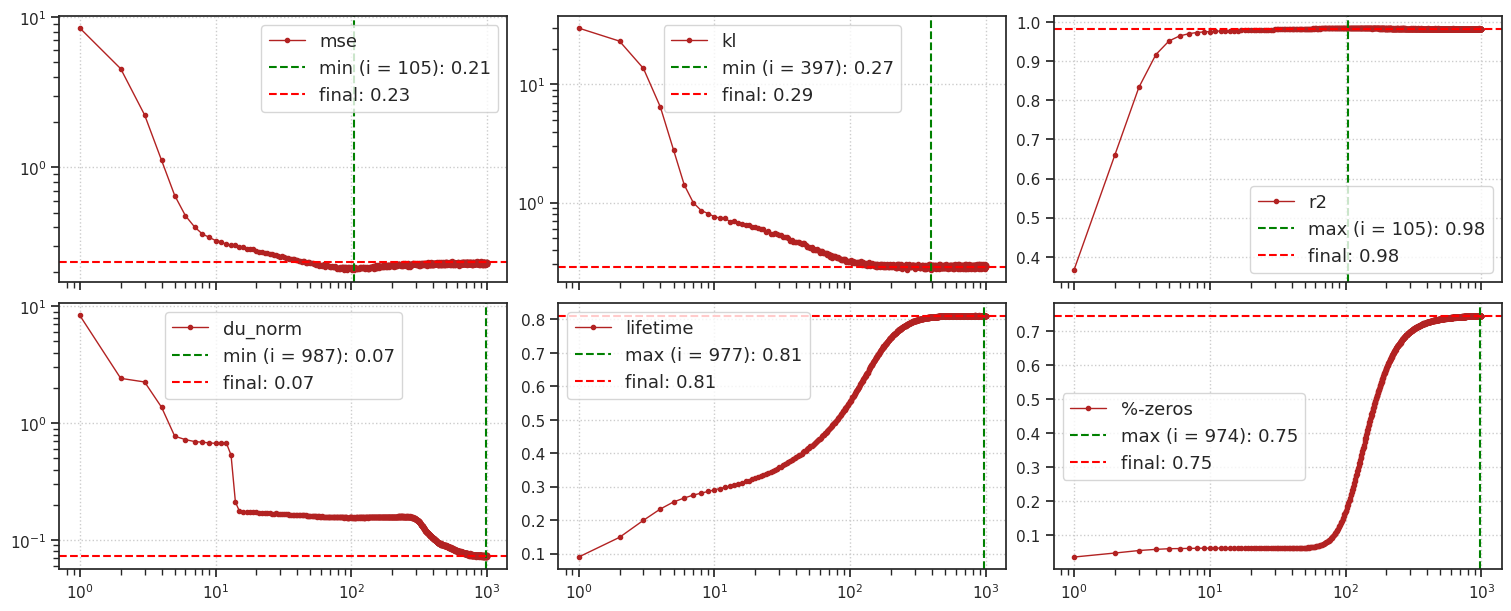

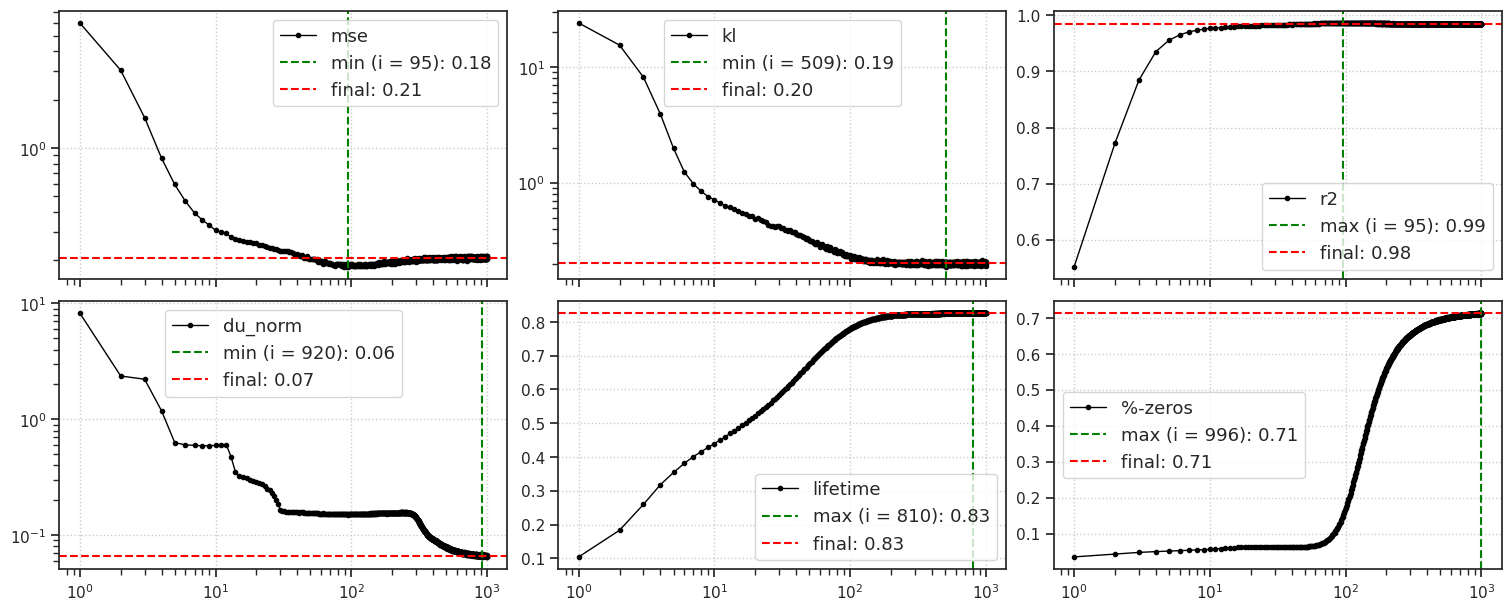

CPU times: user 23.2 s, sys: 303 ms, total: 23.5 s
Wall time: 23.5 s


In [5]:
### Was: Poisson (64, 32.0)

In [8]:
%%time


seq_total = 1000
selection = ['u', 'samples', 'r2']

kws_dl = dict(
    batch_size=1000,
    drop_last=False,
    shuffle=False,
)

results = {}
for item in ['trn', 'vld', 'tst']:
    # create data loader without shuffle
    ds = getattr(tr, f"dl_{item}").dataset
    dl = torch.utils.data.DataLoader(ds, **kws_dl)
    data = collections.defaultdict(list)
    for x, g in tqdm(iter(dl)):
        output = tr.model.xtract_ftr(
            feeder=tr.get_feeder(x),
            seq=range(seq_total),
            return_extras=True,
        ).stack()
        data['g'].append(g)
        for key in selection:
            data[key].append(output[key][:, -1])
        data['lamb'].append(output['u'][:, -1].exp())
    data = {
        k: tonp(torch.cat(v)) for
        k, v in data.items()
    }
    results[item] = data

100%|███████████████████████████████████████████| 50/50 [01:16<00:00,  1.54s/it]

CPU times: user 3min 19s, sys: 213 ms, total: 3min 20s
Wall time: 3min 20s


In [9]:
list(results['trn'])

['g', 'u', 'samples', 'r2', 'lamb']

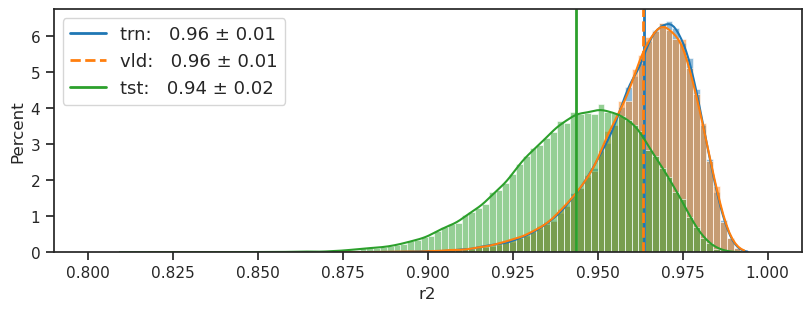

In [10]:
fig, ax = create_figure(1, 1, (8, 3))
for i, (name, d) in enumerate(results.items()):
    sns.histplot(d['r2'], stat='percent', kde=True, bins=np.linspace(0.8, 1.0, 101), color=f"C{i}", ax=ax)
    _a = d['r2'].mean()
    _s = d['r2'].std()
    ls = '--' if name == 'vld' else '-'
    ax.axvline(_a, ls=ls, lw=2, color=f"C{i}", label=f"{name}:   {_a:0.2f} ± {_s:0.2f}")
ax.legend(fontsize=13)
ax.set_xlabel('r2')
plt.show()

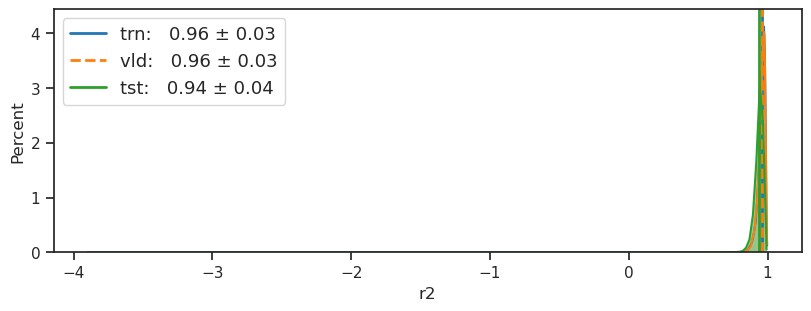

In [8]:
### Was: Gaussian-ReLu (16, 16.0)

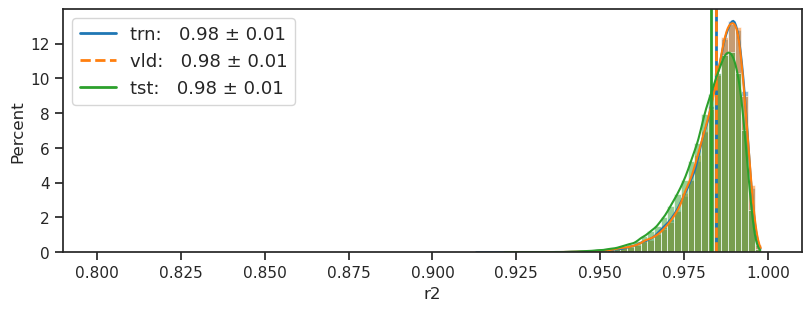

In [8]:
### Was: Poisson (64, 32.0)

In [11]:
var = 'lamb'

lr = LinearRegression().fit(
    X=results['trn'][var],
    y=results['trn']['g'][:, [1, 3]],
)
r2 = {
    name: r2_score(
        y_true=d['g'][:, [1, 3]],
        y_pred=lr.predict(d[var]),
        multioutput='raw_values')
    for name, d in results.items()
}
corr = {
    name: 1 - np.diag(sp_dist.cdist(
        XA=d['g'][:, [1, 3]].T,
        XB=lr.predict(d[var]).T,
        metric='correlation',
    )) for name, d in results.items()
}

In [12]:
print(f"r2:", r2, '\nCorr:', corr)

r2:
{
    'trn': array([0.97749501, 0.97289373]),
    'vld': array([0.97742369, 0.97249866]),
    'tst': array([0.7966253 , 0.70748779])
}

Corr:
{
    'trn': array([0.98868347, 0.98635376]),
    'vld': array([0.98864813, 0.98615793]),
    'tst': array([0.93173729, 0.87043314])
}

In [10]:
### Was: Gaussian-ReLu (16, 16.0)

r2:
{
    'trn': array([0.98336867, 0.98539637]),
    'vld': array([0.98352766, 0.98538645]),
    'tst': array([0.33041873, 0.27238691])
}

Corr:
{
    'trn': array([0.99164947, 0.99267133]),
    'vld': array([0.99173539, 0.99266744]),
    'tst': array([0.9345257 , 0.94180936])
}

In [10]:
### Was: Poisson (64, 32.0)

r2:
{
    'trn': array([0.99777074, 0.99760639]),
    'vld': array([0.99778497, 0.99763561]),
    'tst': array([0.98372213, 0.98344336])
}

Corr:
{
    'trn': array([0.99888475, 0.99880248]),
    'vld': array([0.99889188, 0.99881721]),
    'tst': array([0.99269476, 0.9927593 ])
}

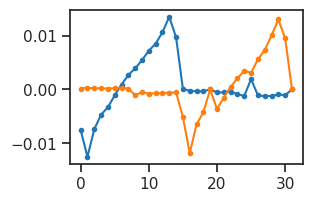

In [11]:
plot(lr.coef_.T[ordered_indices], marker='.')
plt.show()

## Plot repres.

In [13]:
feeder = tr.get_feeder()

output = tr.model.xtract_ftr(
    feeder=feeder,
    seq=range(1000),
    return_extras=True,
).stack()

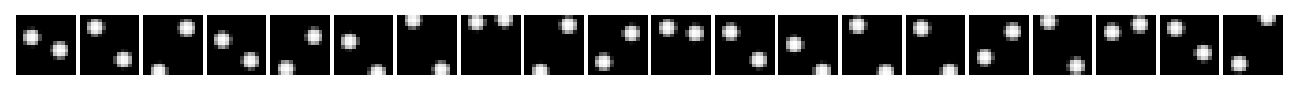

In [14]:
plot_weights(feeder.x[:20], nrows=1);

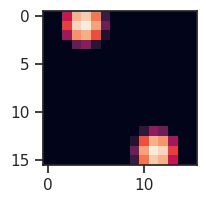

In [15]:
stim_i = 6
imshow(feeder.x[stim_i])
plt.show()

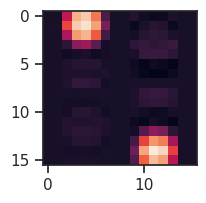

In [16]:
recon = output['recon'][stim_i, -1]
imshow(recon.reshape(16, 16))
plt.show()

In [17]:
output['r2'][stim_i, -1]

tensor(0.9651, device='cuda:0')

In [18]:
spks = output['samples'][stim_i, -1]
spks

tensor([0.2328, 0.2411, 0.8055, 0.2228, 0.5895, 0.7070, 0.7029, 0.1652, 0.7068,
        0.7607, 0.1850, 0.1486, 0.8722, 0.5645, 0.1862, 0.2362, 0.7760, 0.1472,
        0.1362, 0.8764, 0.9052, 0.7117, 0.5790, 0.1346, 0.2429, 0.7996, 0.2450,
        0.1527, 0.1308, 0.6506, 0.6006, 0.1388], device='cuda:0')

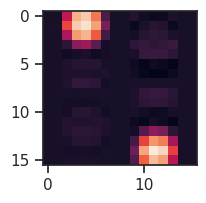

In [19]:
y = tr.model.layer.phi(spks)
imshow(y.reshape(16, 16))
plt.show()

In [20]:
spks[ordered_indices]

tensor([0.7029, 0.7117, 0.7070, 0.1652, 0.7607, 0.1486, 0.2228, 0.2411, 0.1362,
        0.7996, 0.5790, 0.2450, 0.1862, 0.1527, 0.1388, 0.7068, 0.6006, 0.2328,
        0.2429, 0.9052, 0.2362, 0.5895, 0.1472, 0.1850, 0.8055, 0.1346, 0.5645,
        0.7760, 0.8722, 0.6506, 0.8764, 0.1308], device='cuda:0')

In [21]:
np.linalg.norm(w, axis=(1, 2))

array([1.6190481 , 1.1605586 , 1.5490754 , 1.2074382 , 1.6044188 ,
       1.230573  , 1.6448245 , 1.1694691 , 0.93628305, 1.5595422 ,
       1.393969  , 1.4999427 , 1.56519   , 1.0203127 , 1.2707357 ,
       1.2368214 , 1.3478508 , 1.1639862 , 1.1118766 , 1.2769263 ,
       0.99740094, 1.1234082 , 0.98646957, 1.0461917 , 1.288474  ,
       0.8611832 , 1.2180887 , 1.2274992 , 1.2909596 , 0.98302805,
       1.2456696 , 1.2467978 ], dtype=float32)

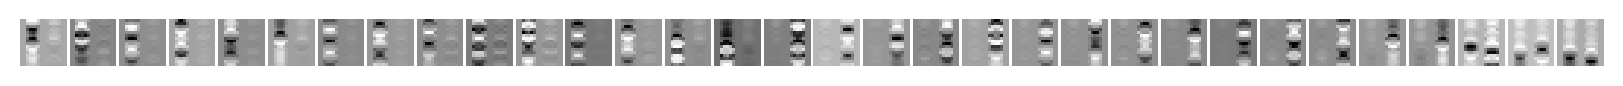

In [22]:
tr.model.show(order=ordered_indices, nrows=1);

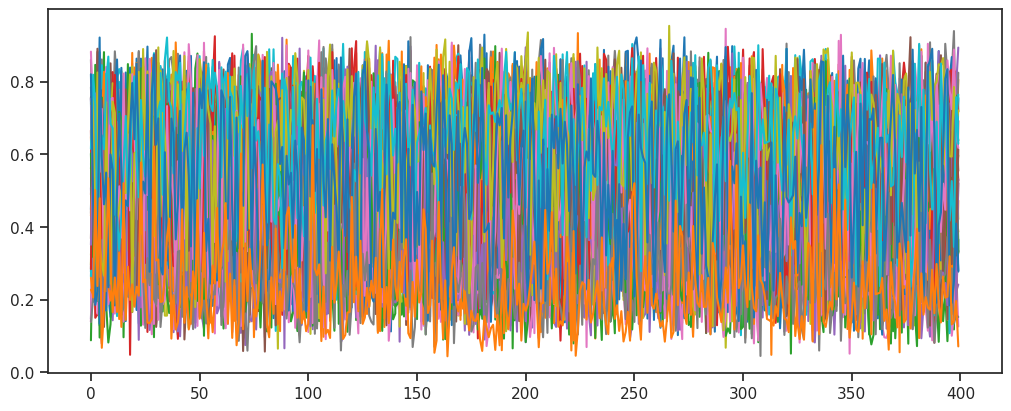

In [23]:
_ = create_figure(1, 1, (10, 4))
plot(output['samples'][:, 0])
plt.show()